In [2]:
# All libraries needed for data pulling, modeling, visualization, and export

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import requests
import warnings
import io
import os

warnings.filterwarnings('ignore')

# Display settings — makes DataFrames easier to read in notebook output
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("All libraries loaded successfully.")
print("Project: Retail Banking Budget Cycle Simulator — 3-Year Strategic Plan & Scenario Engine")
print("Data Sources: FRED (Federal Reserve), BLS NAICS 5221 benchmarks, Simulated division financials")
print("Disclaimer: This is a financial modeling exercise. Does not use proprietary PNC data.")

All libraries loaded successfully.
Project: Retail Banking Budget Cycle Simulator — 3-Year Strategic Plan & Scenario Engine
Data Sources: FRED (Federal Reserve), BLS NAICS 5221 benchmarks, Simulated division financials
Disclaimer: This is a financial modeling exercise. Does not use proprietary PNC data.


In [5]:
# FRED CSVs have two columns but the header name varies — we read without
# assuming column names and rename them manually after loading

FRED_BASE = "https://fred.stlouisfed.org/graph/fredgraph.csv?id="

def pull_fred_series(series_id: str, col_name: str) -> pd.DataFrame:
    """Download a FRED series, parse dates, rename value column."""
    url = FRED_BASE + series_id
    try:
        # Read without parse_dates first so we can inspect what came back
        df = pd.read_csv(url)
        
        # Print columns on first call so we can see exactly what FRED returns
        print(f"  {series_id} raw columns: {df.columns.tolist()}")
        
        # FRED always returns exactly 2 columns — rename them regardless of header
        df.columns = ["date", col_name]
        
        # Now parse the date column manually
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        
        # Drop any rows where date or value failed to parse
        df = df.dropna()
        
        return df
    except Exception as e:
        print(f"WARNING: Could not pull {series_id} from FRED — {e}")
        return None

# Pull the three core macro series
fedfunds_raw = pull_fred_series("FEDFUNDS", "fed_funds_rate")
gdp_raw      = pull_fred_series("GDP",      "gdp")
unrate_raw   = pull_fred_series("UNRATE",   "unemployment_rate")

# Confirm pulls worked before printing lengths
for name, df in [("FEDFUNDS", fedfunds_raw), ("GDP", gdp_raw), ("UNRATE", unrate_raw)]:
    if df is not None:
        print(f"  {name}: {len(df)} observations — date range {df['date'].min().date()} to {df['date'].max().date()}")
    else:
        print(f"  {name}: FAILED — check internet connection or FRED availability")

  FEDFUNDS raw columns: ['observation_date', 'FEDFUNDS']
  GDP raw columns: ['observation_date', 'GDP']
  UNRATE raw columns: ['observation_date', 'UNRATE']
  FEDFUNDS: 861 observations — date range 1954-07-01 to 2026-03-01
  GDP: 316 observations — date range 1947-01-01 to 2025-10-01
  UNRATE: 938 observations — date range 1948-01-01 to 2026-03-01


In [6]:
# SECTION 2B — Convert to Quarterly Averages and Filter 2018–2024
# Monthly series averaged to quarterly so all three series share the same time axis

def to_quarterly_avg(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Resample a monthly series to quarterly average."""
    df = df.set_index("date")
    df_q = df.resample("QS").mean()
    df_q.index = df_q.index.to_period("Q")
    return df_q.reset_index().rename(columns={"date": "quarter"})

fedfunds_q = to_quarterly_avg(fedfunds_raw, "fed_funds_rate")
unrate_q   = to_quarterly_avg(unrate_raw,  "unemployment_rate")

# GDP is already quarterly — just align the index format
gdp_work = gdp_raw.copy()
gdp_work["quarter"] = gdp_work["date"].dt.to_period("Q")
gdp_work = gdp_work[["quarter", "gdp"]]
gdp_work["gdp_growth"] = gdp_work["gdp"].pct_change() * 100

# Merge all three on quarter
macro = fedfunds_q.merge(unrate_q, on="quarter").merge(gdp_work, on="quarter")
macro = macro.dropna()

# Filter to 2018 Q1 – 2024 Q4
macro = macro[
    (macro["quarter"] >= pd.Period("2018Q1")) &
    (macro["quarter"] <= pd.Period("2024Q4"))
].reset_index(drop=True)

print(f"Macro DataFrame shape: {macro.shape}")
print(f"Date range: {macro['quarter'].min()} → {macro['quarter'].max()}")
print(macro.head(10).to_string())

Macro DataFrame shape: (28, 5)
Date range: 2018Q1 → 2024Q4
  quarter  fed_funds_rate  unemployment_rate       gdp  gdp_growth
0  2018Q1            1.45               4.03 20,328.55        1.45
1  2018Q2            1.74               3.93 20,580.91        1.24
2  2018Q3            1.92               3.77 20,798.73        1.06
3  2018Q4            2.22               3.83 20,917.87        0.57
4  2019Q1            2.40               3.87 21,111.60        0.93
5  2019Q2            2.40               3.63 21,397.94        1.36
6  2019Q3            2.19               3.60 21,717.17        1.49
7  2019Q4            1.64               3.60 21,933.22        0.99
8  2020Q1            1.26               3.83 21,751.24       -0.83
9  2020Q2            0.06              13.00 19,958.29       -8.24


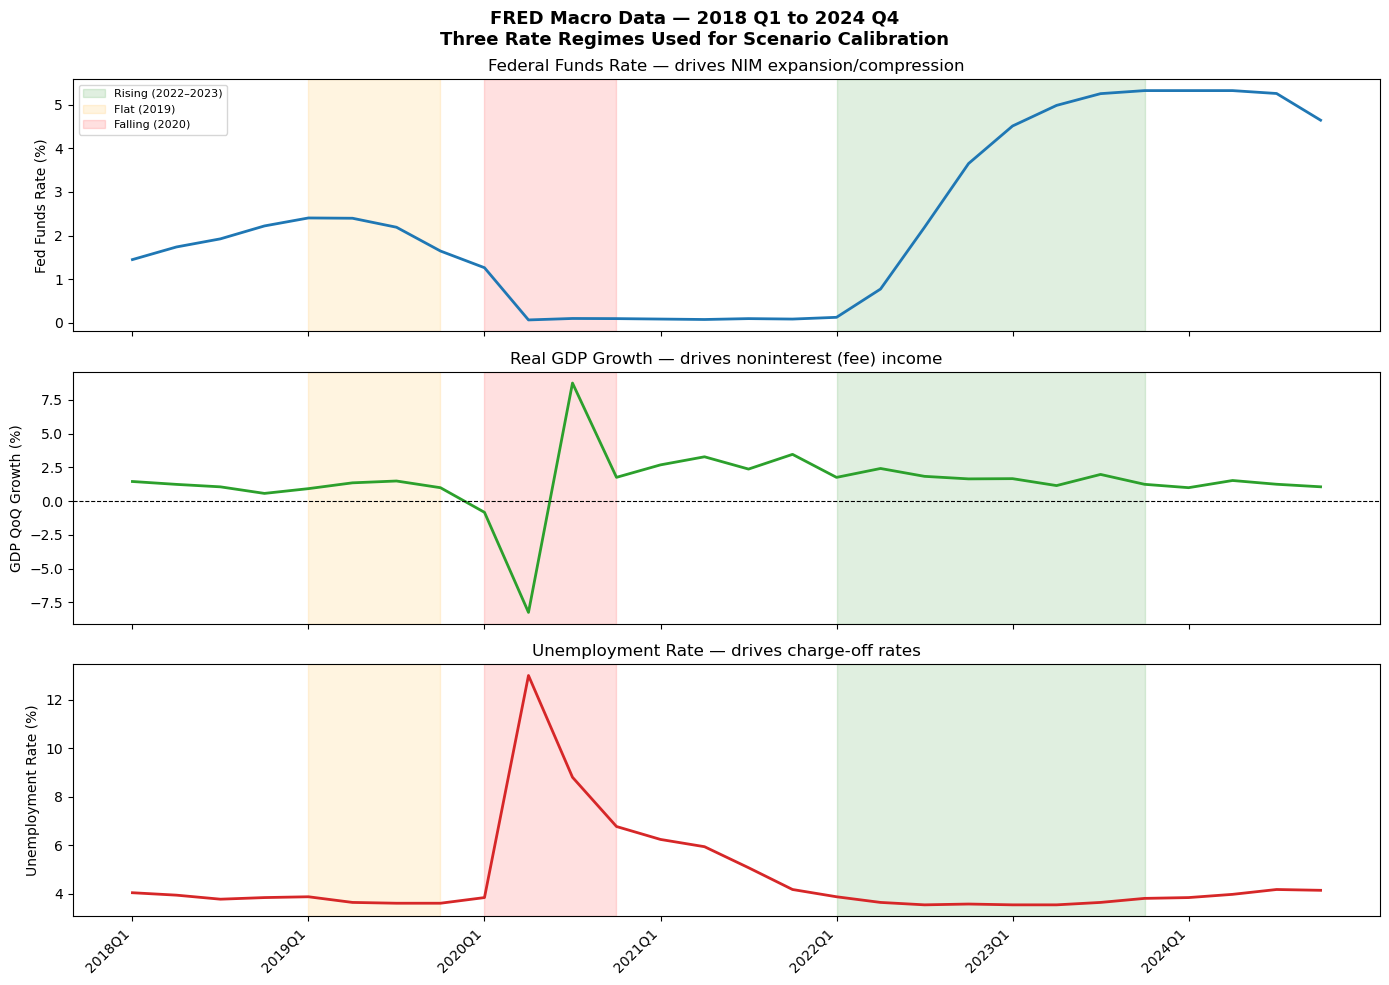

Chart saved: fred_macro_overview.png


In [7]:
# SECTION 2C — Plot All Three FRED Series and Highlight Scenario Periods
# Visual confirmation of the three rate regimes used for scenario calibration

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("FRED Macro Data — 2018 Q1 to 2024 Q4\nThree Rate Regimes Used for Scenario Calibration",
             fontsize=13, fontweight="bold")

quarters_str = macro["quarter"].astype(str).tolist()
x_range      = list(range(len(quarters_str)))

# Helper: find integer index of a quarter label in our list
def q_idx(q_str):
    try:
        return quarters_str.index(q_str)
    except ValueError:
        return None

# Fed Funds Rate
axes[0].plot(x_range, macro["fed_funds_rate"].tolist(), color="#1f77b4", linewidth=2)
axes[0].set_ylabel("Fed Funds Rate (%)")
axes[0].set_title("Federal Funds Rate — drives NIM expansion/compression")

# GDP Growth
axes[1].plot(x_range, macro["gdp_growth"].tolist(), color="#2ca02c", linewidth=2)
axes[1].set_ylabel("GDP QoQ Growth (%)")
axes[1].set_title("Real GDP Growth — drives noninterest (fee) income")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

# Unemployment Rate
axes[2].plot(x_range, macro["unemployment_rate"].tolist(), color="#d62728", linewidth=2)
axes[2].set_ylabel("Unemployment Rate (%)")
axes[2].set_title("Unemployment Rate — drives charge-off rates")

# Shade scenario periods on all three subplots
for ax in axes:
    ax.axvspan(q_idx("2022Q1"), q_idx("2023Q4"), alpha=0.12, color="green",  label="Rising (2022–2023)")
    ax.axvspan(q_idx("2019Q1"), q_idx("2019Q4"), alpha=0.12, color="orange", label="Flat (2019)")
    ax.axvspan(q_idx("2020Q1"), q_idx("2020Q4"), alpha=0.12, color="red",    label="Falling (2020)")

axes[0].legend(fontsize=8, loc="upper left")

# X axis labels — show every 4th quarter to avoid crowding
axes[2].set_xticks(range(0, len(quarters_str), 4))
axes[2].set_xticklabels(quarters_str[::4], rotation=45, ha="right")

plt.tight_layout()
plt.savefig("fred_macro_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fred_macro_overview.png")

In [8]:
# SECTION 2D — Extract Scenario Averages from Historical Periods
# Each scenario collapses to a dict of average macro values
# that feeds directly into the projection engine in Section 4

def scenario_avg(period_start, period_end, label):
    mask = (
        (macro["quarter"] >= pd.Period(period_start)) &
        (macro["quarter"] <= pd.Period(period_end))
    )
    sub = macro[mask]
    return {
        "scenario":         label,
        "avg_fed_funds":    sub["fed_funds_rate"].mean(),
        "avg_gdp_growth":   sub["gdp_growth"].mean(),
        "avg_unemployment": sub["unemployment_rate"].mean(),
        "period":           f"{period_start} – {period_end}"
    }

scenario_rising  = scenario_avg("2022Q1", "2023Q4", "Rising Rate")
scenario_flat    = scenario_avg("2019Q1", "2019Q4", "Flat Rate")
scenario_falling = scenario_avg("2020Q1", "2020Q4", "Falling Rate")

for s in [scenario_rising, scenario_flat, scenario_falling]:
    print(f"\nScenario : {s['scenario']}  ({s['period']})")
    print(f"  Avg Fed Funds    : {s['avg_fed_funds']:.2f}%")
    print(f"  Avg GDP Growth   : {s['avg_gdp_growth']:.2f}%")
    print(f"  Avg Unemployment : {s['avg_unemployment']:.2f}%")


Scenario : Rising Rate  (2022Q1 – 2023Q4)
  Avg Fed Funds    : 3.35%
  Avg GDP Growth   : 1.71%
  Avg Unemployment : 3.64%

Scenario : Flat Rate  (2019Q1 – 2019Q4)
  Avg Fed Funds    : 2.16%
  Avg GDP Growth   : 1.19%
  Avg Unemployment : 3.67%

Scenario : Falling Rate  (2020Q1 – 2020Q4)
  Avg Fed Funds    : 0.38%
  Avg GDP Growth   : 0.36%
  Avg Unemployment : 8.10%


In [9]:
# SECTION 3 — Construct Year 0 Baseline Income Statement
# All line items derived from industry benchmarks or standard banking formulas
# This is the actuals anchor that all three scenario projections grow from

avg_loans_M        = 8_500.0
avg_deposits_M     = 11_200.0
nim_base           = 0.031

net_interest_income_M = avg_loans_M * nim_base
noninterest_income_M  = 420.0
total_revenue_M       = net_interest_income_M + noninterest_income_M

efficiency_ratio      = 0.61
noninterest_expense_M = total_revenue_M * efficiency_ratio

charge_off_rate       = 0.0045
provision_M           = avg_loans_M * charge_off_rate

pretax_income_M       = total_revenue_M - noninterest_expense_M - provision_M
tax_rate              = 0.25
net_income_M          = pretax_income_M * (1 - tax_rate)

fte_per_billion       = 21
fte_count             = round((avg_loans_M / 1_000) * fte_per_billion)
avg_comp_per_fte_K    = 85.0
total_comp_M          = (fte_count * avg_comp_per_fte_K) / 1_000

baseline = pd.DataFrame({
    "Line Item": [
        "Average Loans ($M)", "Average Deposits ($M)", "Net Interest Margin (%)",
        "Net Interest Income ($M)", "Noninterest Income ($M)", "Total Revenue ($M)",
        "Efficiency Ratio (%)", "Noninterest Expense ($M)", "Provision for Credit Losses ($M)",
        "Pre-Tax Income ($M)", "Tax Rate (%)", "Net Income ($M)",
        "FTE Count", "Avg Compensation per FTE ($K)", "Total Comp Expense ($M)"
    ],
    "Year 0 (Actual)": [
        avg_loans_M, avg_deposits_M, nim_base * 100,
        round(net_interest_income_M, 1), noninterest_income_M, round(total_revenue_M, 1),
        efficiency_ratio * 100, round(noninterest_expense_M, 1), round(provision_M, 1),
        round(pretax_income_M, 1), tax_rate * 100, round(net_income_M, 1),
        fte_count, avg_comp_per_fte_K, round(total_comp_M, 1)
    ],
    "Driver / Benchmark": [
        "Starting balance", "LTD ratio ~76%", "Mid-cycle; industry 2.8–3.4%",
        "Loans × NIM", "Fees & service charges", "NII + Noninterest Income",
        "Industry benchmark 58–65%", "Revenue × Efficiency Ratio", "Loans × 0.45% charge-off rate",
        "Revenue − Expense − Provision", "Standard corporate rate", "Pre-Tax × (1 − 25%)",
        "Loans ($B) × 21 FTE/$B", "BLS NAICS 5221 benchmark", "FTE × Avg Comp / 1000"
    ]
})

print("\n" + "="*70)
print("YEAR 0 BASELINE — RETAIL BANKING DIVISION")
print("="*70)
print(baseline.to_string(index=False))


YEAR 0 BASELINE — RETAIL BANKING DIVISION
                       Line Item  Year 0 (Actual)            Driver / Benchmark
              Average Loans ($M)         8,500.00              Starting balance
           Average Deposits ($M)        11,200.00                LTD ratio ~76%
         Net Interest Margin (%)             3.10  Mid-cycle; industry 2.8–3.4%
        Net Interest Income ($M)           263.50                   Loans × NIM
         Noninterest Income ($M)           420.00        Fees & service charges
              Total Revenue ($M)           683.50      NII + Noninterest Income
            Efficiency Ratio (%)            61.00     Industry benchmark 58–65%
        Noninterest Expense ($M)           416.90    Revenue × Efficiency Ratio
Provision for Credit Losses ($M)            38.20 Loans × 0.45% charge-off rate
             Pre-Tax Income ($M)           228.30 Revenue − Expense − Provision
                    Tax Rate (%)            25.00       Standard corporate ra

In [10]:
# SECTION 4A — Define Scenario Parameters
# Each scenario maps macro conditions to specific financial drivers
# All values grounded in FRED historical averages from Section 2D

SCENARIO_PARAMS = {
    "Rising Rate": {
        "loan_growth_rate":   0.06,
        "nim_change_bps":    +15,
        "gdp_growth":         0.025,
        "unemployment_delta": -0.3,
        "base_charge_off":    0.0035,
        "color":              "#2ecc71"
    },
    "Flat Rate": {
        "loan_growth_rate":   0.045,
        "nim_change_bps":      0,
        "gdp_growth":          0.022,
        "unemployment_delta":  0.0,
        "base_charge_off":     0.0045,
        "color":               "#3498db"
    },
    "Falling Rate": {
        "loan_growth_rate":    0.03,
        "nim_change_bps":     -20,
        "gdp_growth":          0.005,
        "unemployment_delta": +0.8,
        "base_charge_off":     0.0065,
        "color":               "#e74c3c"
    }
}

print("Scenario parameters defined:")
for name, params in SCENARIO_PARAMS.items():
    print(f"\n  {name}:")
    for k, v in params.items():
        if k != "color":
            print(f"    {k}: {v}")

Scenario parameters defined:

  Rising Rate:
    loan_growth_rate: 0.06
    nim_change_bps: 15
    gdp_growth: 0.025
    unemployment_delta: -0.3
    base_charge_off: 0.0035

  Flat Rate:
    loan_growth_rate: 0.045
    nim_change_bps: 0
    gdp_growth: 0.022
    unemployment_delta: 0.0
    base_charge_off: 0.0045

  Falling Rate:
    loan_growth_rate: 0.03
    nim_change_bps: -20
    gdp_growth: 0.005
    unemployment_delta: 0.8
    base_charge_off: 0.0065


In [11]:
# SECTION 4B — Core Projection Function
# Projects a full 3-year income statement from Year 0 baseline
# Each driver follows its own adjustment logic mirroring real bank planning models

def project_scenario(scenario_name, params, n_years=3):
    loans         = avg_loans_M
    nim           = nim_base
    charge_off    = params["base_charge_off"]
    eff_ratio     = efficiency_ratio
    nonint_inc    = noninterest_income_M
    loans_prev    = avg_loans_M

    rows = []

    for yr in range(1, n_years + 1):

        loans      = loans * (1 + params["loan_growth_rate"])
        nim        = max(nim + (params["nim_change_bps"] / 10_000), 0.020)
        nii        = loans * nim
        nonint_inc = nonint_inc * (1 + params["gdp_growth"])
        charge_off = max(charge_off + (params["unemployment_delta"] * 0.001), 0.002)
        provision  = loans * charge_off
        total_rev  = nii + nonint_inc
        eff_ratio  = max(eff_ratio - 0.005, 0.50)
        nonint_exp = total_rev * eff_ratio
        pretax     = total_rev - nonint_exp - provision
        net_inc    = pretax * (1 - tax_rate)

        # FTE hiring lags loan growth by one year — workforce planning cycles take time
        fte        = round((loans_prev / 1_000) * fte_per_billion)
        loans_prev = loans
        total_comp = (fte * avg_comp_per_fte_K) / 1_000

        rows.append({
            "Year":                             f"Year {yr}",
            "Scenario":                         scenario_name,
            "Avg Loans ($M)":                   round(loans, 1),
            "NIM (%)":                          round(nim * 100, 3),
            "Net Interest Income ($M)":         round(nii, 1),
            "Noninterest Income ($M)":          round(nonint_inc, 1),
            "Total Revenue ($M)":               round(total_rev, 1),
            "Efficiency Ratio (%)":             round(eff_ratio * 100, 2),
            "Noninterest Expense ($M)":         round(nonint_exp, 1),
            "Provision for Credit Losses ($M)": round(provision, 1),
            "Pre-Tax Income ($M)":              round(pretax, 1),
            "Net Income ($M)":                  round(net_inc, 1),
            "FTE Count":                        fte,
            "Total Comp Expense ($M)":          round(total_comp, 1),
            "Charge-Off Rate (%)":              round(charge_off * 100, 3),
            "FTE per $B Loans":                 round(fte / (loans / 1_000), 2)
        })

    return pd.DataFrame(rows)

# Run all three scenarios
scenario_results = {}
for name, params in SCENARIO_PARAMS.items():
    scenario_results[name] = project_scenario(name, params)
    print(f"\n{'='*60}")
    print(f"SCENARIO: {name}")
    print("="*60)
    print(scenario_results[name][
        ["Year", "Avg Loans ($M)", "NIM (%)", "Total Revenue ($M)",
         "Net Income ($M)", "FTE Count"]
    ].to_string(index=False))


SCENARIO: Rising Rate
  Year  Avg Loans ($M)  NIM (%)  Total Revenue ($M)  Net Income ($M)  FTE Count
Year 1        9,010.00     3.25              723.30           192.70        178
Year 2        9,550.60     3.40              766.00           209.00        189
Year 3       10,123.60     3.55              811.70           226.80        201

SCENARIO: Flat Rate
  Year  Avg Loans ($M)  NIM (%)  Total Revenue ($M)  Net Income ($M)  FTE Count
Year 1        8,882.50     3.10              704.60           178.80        178
Year 2        9,282.20     3.10              726.40           186.60        187
Year 3        9,699.90     3.10              749.00           194.80        195

SCENARIO: Falling Rate
  Year  Avg Loans ($M)  NIM (%)  Total Revenue ($M)  Net Income ($M)  FTE Count
Year 1        8,755.00     2.90              676.00           152.30        178
Year 2        9,017.60     2.70              667.70           145.50        184
Year 3        9,288.20     2.50              658.50 

In [12]:
# SECTION 5A — Staffing Forecast: FTE Productivity Ratios and Alerts
# Staffing is a distinct planning deliverable — comp is 50-60% of noninterest expense

FTE_LOWER = 18
FTE_UPPER = 24

print("\n" + "="*70)
print("STAFFING FORECAST — FTE BY SCENARIO")
print("="*70)

for name, df in scenario_results.items():
    print(f"\n--- {name} ---")
    for _, row in df.iterrows():
        fte_ratio = row["FTE per $B Loans"]
        comp_pct  = (row["Total Comp Expense ($M)"] / row["Noninterest Expense ($M)"]) * 100
        alert     = ""
        if fte_ratio < FTE_LOWER:
            alert = "  ⚠️  UNDERSTAFFING RISK — below 18 FTE/$B benchmark"
        elif fte_ratio > FTE_UPPER:
            alert = "  ⚠️  OVERSTAFFING — above 24 FTE/$B benchmark (efficiency drag)"
        print(f"  {row['Year']}: FTE={row['FTE Count']:,} | "
              f"FTE per $B={fte_ratio:.1f} | "
              f"Comp={row['Total Comp Expense ($M)']:.1f}M "
              f"({comp_pct:.1f}% of OpEx){alert}")


STAFFING FORECAST — FTE BY SCENARIO

--- Rising Rate ---
  Year 1: FTE=178 | FTE per $B=19.8 | Comp=15.1M (3.5% of OpEx)
  Year 2: FTE=189 | FTE per $B=19.8 | Comp=16.1M (3.5% of OpEx)
  Year 3: FTE=201 | FTE per $B=19.9 | Comp=17.1M (3.5% of OpEx)

--- Flat Rate ---
  Year 1: FTE=178 | FTE per $B=20.0 | Comp=15.1M (3.5% of OpEx)
  Year 2: FTE=187 | FTE per $B=20.1 | Comp=15.9M (3.6% of OpEx)
  Year 3: FTE=195 | FTE per $B=20.1 | Comp=16.6M (3.7% of OpEx)

--- Falling Rate ---
  Year 1: FTE=178 | FTE per $B=20.3 | Comp=15.1M (3.7% of OpEx)
  Year 2: FTE=184 | FTE per $B=20.4 | Comp=15.6M (3.9% of OpEx)
  Year 3: FTE=189 | FTE per $B=20.4 | Comp=16.1M (4.1% of OpEx)


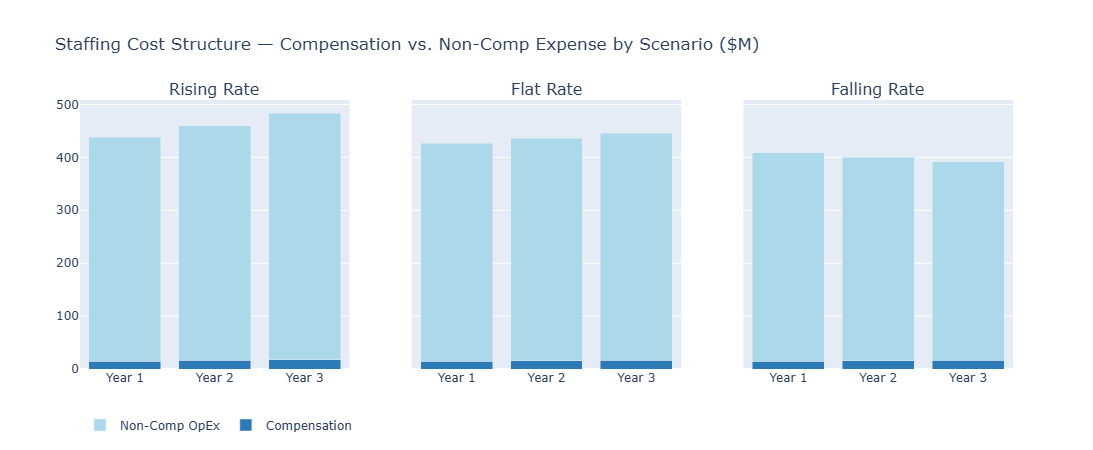

In [13]:
# SECTION 5B — Stacked Bar Chart: Comp vs Non-Comp Expense
# Shows management where cost pressure lives and whether productivity
# gains are flowing through to the expense line

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=list(scenario_results.keys()),
                    shared_yaxes=True)

for col_idx, (name, df) in enumerate(scenario_results.items(), start=1):
    comp_vals    = df["Total Comp Expense ($M)"].tolist()
    noncomp_vals = (df["Noninterest Expense ($M)"] - df["Total Comp Expense ($M)"]).tolist()
    years        = df["Year"].tolist()

    fig.add_trace(go.Bar(
        name="Compensation",
        x=years, y=comp_vals,
        marker_color="#2c7bb6",
        showlegend=(col_idx == 1)
    ), row=1, col=col_idx)

    fig.add_trace(go.Bar(
        name="Non-Comp OpEx",
        x=years, y=noncomp_vals,
        marker_color="#abd9e9",
        showlegend=(col_idx == 1)
    ), row=1, col=col_idx)

fig.update_layout(
    barmode="stack",
    title_text="Staffing Cost Structure — Compensation vs. Non-Comp Expense by Scenario ($M)",
    height=450,
    legend=dict(orientation="h", y=-0.15)
)
fig.show()

In [14]:
# SECTION 6A — One-Way Sensitivity Tables: Rate and Volume Impact
# Standard senior management deliverable showing full range of outcomes
# under independent shocks to rate and volume assumptions

base_params  = SCENARIO_PARAMS["Flat Rate"].copy()
base_df      = scenario_results["Flat Rate"]
base_net_inc = base_df[base_df["Year"] == "Year 3"]["Net Income ($M)"].values[0]

# Rate sensitivity: each 100bps rate shock = ~12bps NIM impact (asset-sensitive bank)
rate_shocks_bps = [-100, -50, 0, +50, +100]
rate_rows = []

for shock in rate_shocks_bps:
    nim_delta_bps  = shock * 0.12
    shocked_params = base_params.copy()
    shocked_params["nim_change_bps"] = base_params["nim_change_bps"] + nim_delta_bps
    shocked_df     = project_scenario("Sensitivity", shocked_params)
    shocked_ni     = shocked_df[shocked_df["Year"] == "Year 3"]["Net Income ($M)"].values[0]
    delta          = shocked_ni - base_net_inc
    delta_pct      = (delta / base_net_inc) * 100
    rate_rows.append({
        "Rate Shock (bps)":           f"{shock:+d} bps",
        "NIM Impact (bps)":           f"{nim_delta_bps:+.1f} bps",
        "Year 3 Net Income ($M)":     round(shocked_ni, 1),
        "Change vs. Base ($M)":       round(delta, 1),
        "Change vs. Base (%)":        round(delta_pct, 2)
    })

rate_sensitivity_df = pd.DataFrame(rate_rows)

# Volume sensitivity: vary loan growth rate independently
vol_shocks = [-0.05, -0.025, 0.0, +0.025, +0.05]
vol_rows = []

for shock in vol_shocks:
    shocked_params = base_params.copy()
    shocked_params["loan_growth_rate"] = base_params["loan_growth_rate"] + shock
    shocked_df     = project_scenario("Sensitivity", shocked_params)
    shocked_ni     = shocked_df[shocked_df["Year"] == "Year 3"]["Net Income ($M)"].values[0]
    delta          = shocked_ni - base_net_inc
    delta_pct      = (delta / base_net_inc) * 100
    vol_rows.append({
        "Loan Growth Shock":          f"{shock*100:+.1f}%",
        "Effective Growth Rate":      f"{(base_params['loan_growth_rate']+shock)*100:.1f}%",
        "Year 3 Net Income ($M)":     round(shocked_ni, 1),
        "Change vs. Base ($M)":       round(delta, 1),
        "Change vs. Base (%)":        round(delta_pct, 2)
    })

vol_sensitivity_df = pd.DataFrame(vol_rows)

print(f"Base Case (Flat Rate, Year 3 Net Income): ${base_net_inc:.1f}M\n")
print("RATE SENSITIVITY TABLE:")
print(rate_sensitivity_df.to_string(index=False))
print("\nVOLUME SENSITIVITY TABLE:")
print(vol_sensitivity_df.to_string(index=False))

Base Case (Flat Rate, Year 3 Net Income): $194.8M

RATE SENSITIVITY TABLE:
Rate Shock (bps) NIM Impact (bps)  Year 3 Net Income ($M)  Change vs. Base ($M)  Change vs. Base (%)
        -100 bps        -12.0 bps                  184.20                -10.60                -5.44
         -50 bps         -6.0 bps                  189.50                 -5.30                -2.72
          +0 bps         +0.0 bps                  194.80                  0.00                 0.00
         +50 bps         +6.0 bps                  200.10                  5.30                 2.72
        +100 bps        +12.0 bps                  205.40                 10.60                 5.44

VOLUME SENSITIVITY TABLE:
Loan Growth Shock Effective Growth Rate  Year 3 Net Income ($M)  Change vs. Base ($M)  Change vs. Base (%)
            -5.0%                 -0.5%                  186.80                 -8.00                -4.11
            -2.5%                  2.0%                  190.70               

In [15]:
# SECTION 6B — Color-Gradient Styled Sensitivity Tables
# Green = favorable vs. base; Red = adverse
# Uses .map() instead of .applymap() for pandas 2.x compatibility

def color_delta(val):
    try:
        num = float(str(val).replace(",", "").replace("%", ""))
        if num > 0:
            intensity = min(abs(num) / 30, 1.0)
            return f"background-color: rgba(0,180,0,{intensity * 0.5:.2f})"
        elif num < 0:
            intensity = min(abs(num) / 30, 1.0)
            return f"background-color: rgba(220,0,0,{intensity * 0.5:.2f})"
    except:
        pass
    return ""

print("\n=== RATE SENSITIVITY (styled) ===")
display(rate_sensitivity_df.style.map(
    color_delta, subset=["Change vs. Base ($M)", "Change vs. Base (%)"]
).set_caption("Rate Sensitivity — Year 3 Net Income vs. Flat Rate Base Case"))

print("\n=== VOLUME SENSITIVITY (styled) ===")
display(vol_sensitivity_df.style.map(
    color_delta, subset=["Change vs. Base ($M)", "Change vs. Base (%)"]
).set_caption("Volume Sensitivity — Year 3 Net Income vs. Flat Rate Base Case"))


=== RATE SENSITIVITY (styled) ===


,Rate Shock (bps),NIM Impact (bps),Year 3 Net Income ($M),Change vs. Base ($M),Change vs. Base (%)
0,-100 bps,-12.0 bps,184.200000,-10.600000,-5.440000
1,-50 bps,-6.0 bps,189.500000,-5.300000,-2.720000
2,+0 bps,+0.0 bps,194.800000,0.000000,0.000000
3,+50 bps,+6.0 bps,200.100000,5.300000,2.720000
4,+100 bps,+12.0 bps,205.400000,10.600000,5.440000



=== VOLUME SENSITIVITY (styled) ===


,Loan Growth Shock,Effective Growth Rate,Year 3 Net Income ($M),Change vs. Base ($M),Change vs. Base (%)
0,-5.0%,-0.5%,186.800000,-8.000000,-4.110000
1,-2.5%,2.0%,190.700000,-4.100000,-2.100000
2,+0.0%,4.5%,194.800000,0.000000,0.000000
3,+2.5%,7.0%,199.100000,4.300000,2.210000
4,+5.0%,9.5%,203.600000,8.800000,4.520000


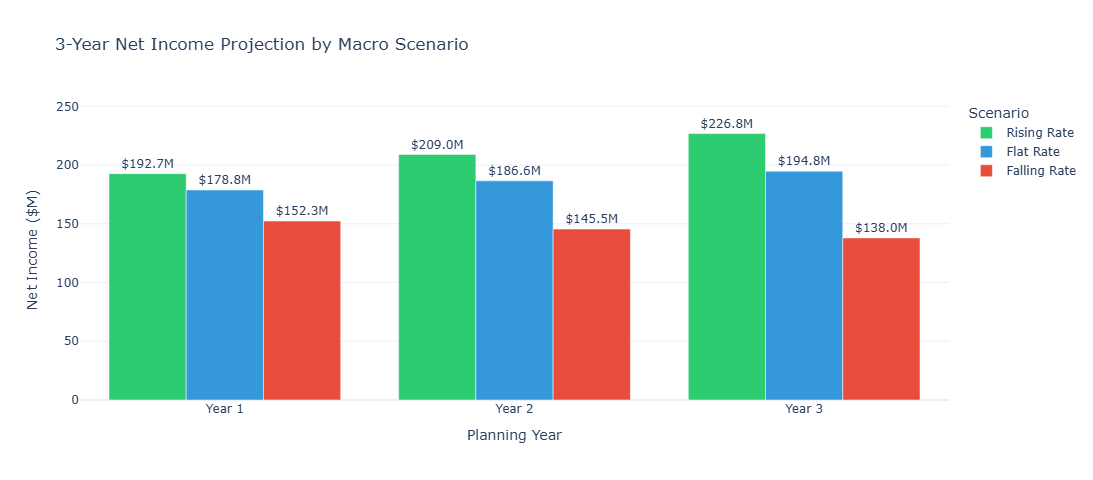

In [16]:
# SECTION 7A — Grouped Bar Chart: Net Income by Year and Scenario
# Primary summary chart for senior management showing full outcome range

years = ["Year 1", "Year 2", "Year 3"]

fig_ni = go.Figure()
for name, df in scenario_results.items():
    ni_vals = df["Net Income ($M)"].tolist()
    fig_ni.add_trace(go.Bar(
        name=name,
        x=years,
        y=ni_vals,
        marker_color=SCENARIO_PARAMS[name]["color"],
        text=[f"${v:.1f}M" for v in ni_vals],
        textposition="outside"
    ))

fig_ni.update_layout(
    barmode="group",
    title="3-Year Net Income Projection by Macro Scenario",
    yaxis_title="Net Income ($M)",
    xaxis_title="Planning Year",
    legend_title="Scenario",
    height=480,
    template="plotly_white"
)
fig_ni.show()

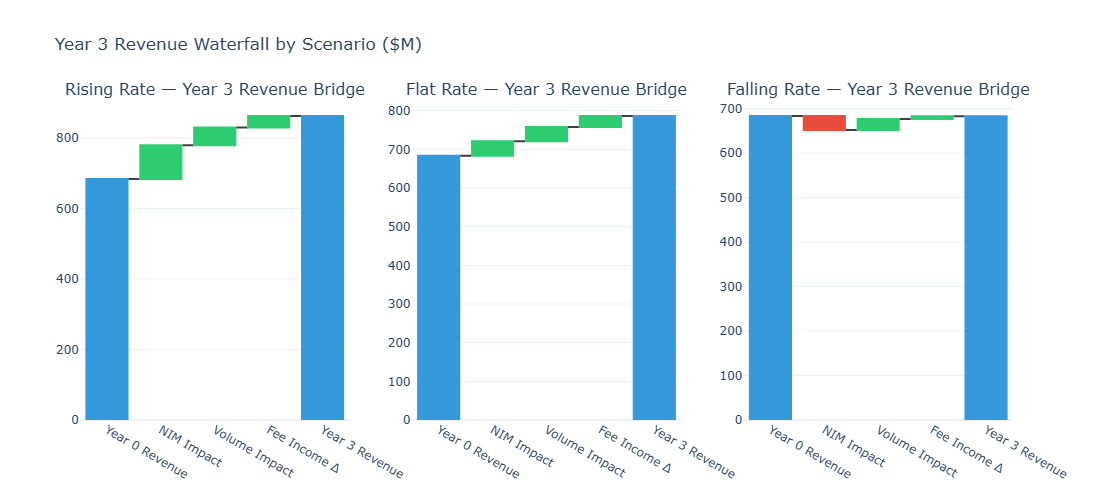

In [17]:
# SECTION 7B — Revenue Waterfall by Scenario (Year 3)
# Tells the story of how macro conditions flow through to the bottom line
# Standard format for executive budget presentations

fig_wf = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"{n} — Year 3 Revenue Bridge" for n in scenario_results]
)

for col_idx, (name, df) in enumerate(scenario_results.items(), start=1):
    yr3        = df[df["Year"] == "Year 3"].iloc[0]
    nim_impact = yr3["Net Interest Income ($M)"] - net_interest_income_M
    vol_impact = (yr3["Avg Loans ($M)"] - avg_loans_M) * nim_base
    fee_impact = yr3["Noninterest Income ($M)"] - noninterest_income_M

    fig_wf.add_trace(go.Waterfall(
        orientation="v",
        measure=["absolute", "relative", "relative", "relative", "total"],
        x=["Year 0 Revenue", "NIM Impact", "Volume Impact", "Fee Income Δ", "Year 3 Revenue"],
        y=[total_revenue_M, nim_impact, vol_impact, fee_impact, yr3["Total Revenue ($M)"]],
        connector={"line": {"color": "rgb(63,63,63)"}},
        increasing={"marker": {"color": "#2ecc71"}},
        decreasing={"marker": {"color": "#e74c3c"}},
        totals={"marker":    {"color": "#3498db"}},
        showlegend=False
    ), row=1, col=col_idx)

fig_wf.update_layout(
    title="Year 3 Revenue Waterfall by Scenario ($M)",
    height=500,
    template="plotly_white"
)
fig_wf.show()

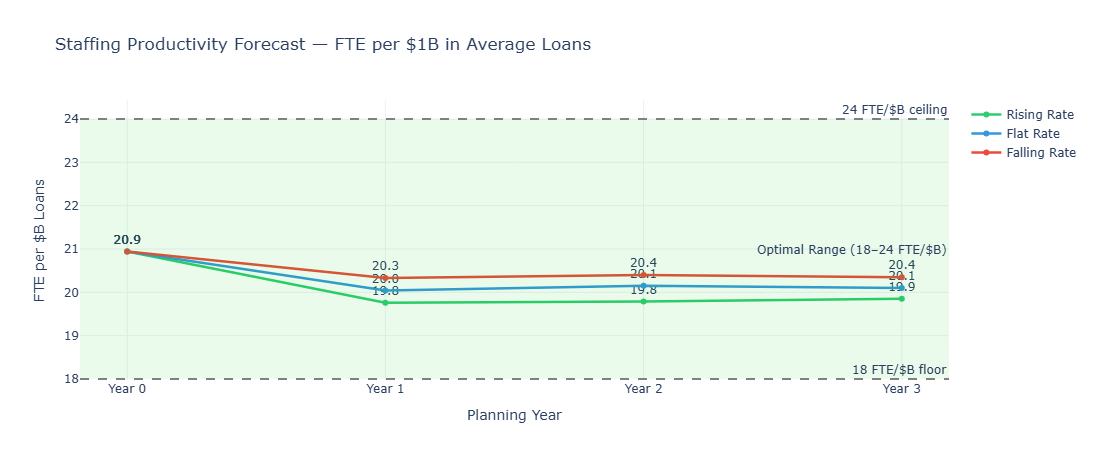

In [18]:
# SECTION 7C — Staffing Forecast Line Chart with Benchmark Band
# Management wants FTE productivity to stay in the 18-24 FTE/$B band
# as loan volume grows — this chart makes deviations immediately visible

fig_fte = go.Figure()
all_years = ["Year 0"] + years

for name, df in scenario_results.items():
    fte_vals = [round(fte_count / (avg_loans_M / 1_000), 2)] + df["FTE per $B Loans"].tolist()
    fig_fte.add_trace(go.Scatter(
        x=all_years,
        y=fte_vals,
        mode="lines+markers+text",
        name=name,
        line=dict(color=SCENARIO_PARAMS[name]["color"], width=2.5),
        text=[f"{v:.1f}" for v in fte_vals],
        textposition="top center"
    ))

fig_fte.add_hrect(
    y0=FTE_LOWER, y1=FTE_UPPER,
    fillcolor="rgba(0,200,0,0.08)",
    line_width=0,
    annotation_text="Optimal Range (18–24 FTE/$B)",
    annotation_position="right"
)
fig_fte.add_hline(y=FTE_LOWER, line_dash="dash", line_color="gray",
                  annotation_text="18 FTE/$B floor")
fig_fte.add_hline(y=FTE_UPPER, line_dash="dash", line_color="gray",
                  annotation_text="24 FTE/$B ceiling")

fig_fte.update_layout(
    title="Staffing Productivity Forecast — FTE per $1B in Average Loans",
    yaxis_title="FTE per $B Loans",
    xaxis_title="Planning Year",
    height=460,
    template="plotly_white"
)
fig_fte.show()

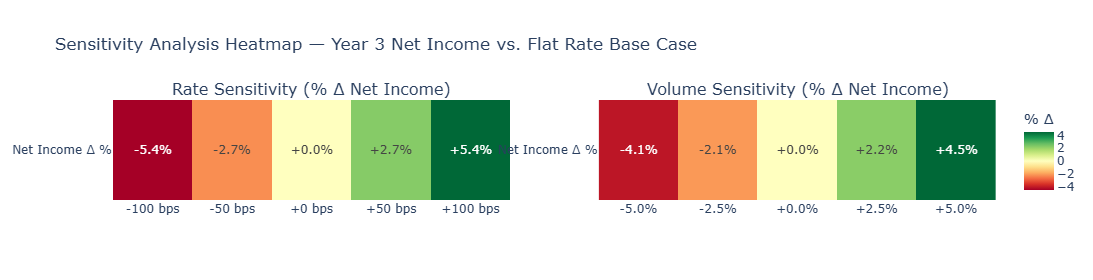

In [19]:
# SECTION 7D — Sensitivity Heatmap
# Condenses sensitivity tables into an at-a-glance visual
# for risk management and scenario planning discussions

rate_labels = rate_sensitivity_df["Rate Shock (bps)"].tolist()
rate_deltas = rate_sensitivity_df["Change vs. Base (%)"].tolist()
vol_labels  = vol_sensitivity_df["Loan Growth Shock"].tolist()
vol_deltas  = vol_sensitivity_df["Change vs. Base (%)"].tolist()

fig_heat = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Rate Sensitivity (% Δ Net Income)",
        "Volume Sensitivity (% Δ Net Income)"
    ]
)

fig_heat.add_trace(go.Heatmap(
    z=[rate_deltas],
    x=rate_labels,
    y=["Net Income Δ %"],
    colorscale="RdYlGn",
    zmid=0,
    text=[[f"{v:+.1f}%" for v in rate_deltas]],
    texttemplate="%{text}",
    showscale=False
), row=1, col=1)

fig_heat.add_trace(go.Heatmap(
    z=[vol_deltas],
    x=vol_labels,
    y=["Net Income Δ %"],
    colorscale="RdYlGn",
    zmid=0,
    text=[[f"{v:+.1f}%" for v in vol_deltas]],
    texttemplate="%{text}",
    showscale=True,
    colorbar=dict(title="% Δ")
), row=1, col=2)

fig_heat.update_layout(
    title="Sensitivity Analysis Heatmap — Year 3 Net Income vs. Flat Rate Base Case",
    height=280,
    template="plotly_white"
)
fig_heat.show()

In [21]:
# SECTION 8 — Multi-Sheet Excel Export
# Finance teams operate in Excel — delivering outputs in their format
# makes this tool immediately usable by real stakeholders

import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

OUTPUT_FILE  = "retail_banking_3yr_plan.xlsx"
HEADER_FILL  = PatternFill("solid", fgColor="1F4E79")
ALT_FILL     = PatternFill("solid", fgColor="D9E1F2")
HEADER_FONT  = Font(bold=True, color="FFFFFF", size=11)
TITLE_FONT   = Font(bold=True, size=13, color="1F4E79")

def write_df_to_sheet(ws, df, sheet_title):
    ws.cell(row=1, column=1, value=sheet_title).font = TITLE_FONT
    for ci, col_name in enumerate(df.columns, 1):
        cell = ws.cell(row=2, column=ci, value=col_name)
        cell.font      = HEADER_FONT
        cell.fill      = HEADER_FILL
        cell.alignment = Alignment(horizontal="center", wrap_text=True)
    for ri, row_data in enumerate(dataframe_to_rows(df, index=False, header=False), 3):
        for ci, value in enumerate(row_data, 1):
            cell = ws.cell(row=ri, column=ci, value=value)
            if ri % 2 == 0:
                cell.fill = ALT_FILL
            if isinstance(value, (int, float)):
                cell.number_format = "#,##0.0"
    for col in ws.columns:
        max_len = max((len(str(c.value)) if c.value else 0) for c in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 30)

wb = openpyxl.Workbook()
wb.remove(wb.active)

# Sheets 1–3: one per scenario
for scenario_name, df in scenario_results.items():
    ws = wb.create_sheet(title=scenario_name[:31])
    write_df_to_sheet(ws, df, f"{scenario_name} — 3-Year Projected Income Statement")

# Sheet 4: staffing forecast all scenarios combined
all_staffing = pd.concat([
    df[["Year", "Scenario", "FTE Count", "FTE per $B Loans",
        "Total Comp Expense ($M)", "Noninterest Expense ($M)"]]
    for name, df in scenario_results.items()
], ignore_index=True)

ws_staff = wb.create_sheet(title="Staffing Forecast")
write_df_to_sheet(ws_staff, all_staffing, "Staffing Forecast — All Scenarios")

# Sheet 5: sensitivity tables
ws_sens = wb.create_sheet(title="Sensitivity Analysis")
write_df_to_sheet(ws_sens, rate_sensitivity_df, "Rate Sensitivity — Year 3 Net Income")

start_row = len(rate_sensitivity_df) + 5
ws_sens.cell(row=start_row, column=1,
             value="Volume Sensitivity — Year 3 Net Income").font = TITLE_FONT
for ci, col_name in enumerate(vol_sensitivity_df.columns, 1):
    cell = ws_sens.cell(row=start_row + 1, column=ci, value=col_name)
    cell.font = HEADER_FONT
    cell.fill = HEADER_FILL
for ri, row_data in enumerate(
    dataframe_to_rows(vol_sensitivity_df, index=False, header=False),
    start=start_row + 2
):
    for ci, value in enumerate(row_data, 1):
        ws_sens.cell(row=ri, column=ci, value=value)

wb.save(OUTPUT_FILE)
print(f"✅ Excel workbook saved: {OUTPUT_FILE}")
print(f"   Sheets: {[ws.title for ws in wb.worksheets]}")

✅ Excel workbook saved: retail_banking_3yr_plan.xlsx
   Sheets: ['Rising Rate', 'Flat Rate', 'Falling Rate', 'Staffing Forecast', 'Sensitivity Analysis']


In [23]:
# ============================================================
# SECTION 9 — Write the Complete Streamlit App to app.py
# Run this cell once — it creates app.py in your project folder
# After this cell runs, open a terminal and run: streamlit run app.py
# ============================================================

app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests
import io
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows

st.set_page_config(
    page_title="Retail Banking Budget Simulator",
    page_icon="Bank",
    layout="wide"
)

@st.cache_data(ttl=3600)
def pull_fred(series_id, col_name):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    try:
        df = pd.read_csv(url)
        df.columns = ["date", col_name]
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        return df.dropna()
    except:
        return None

AVG_LOANS_M        = 8_500.0
AVG_DEPOSITS_M     = 11_200.0
NIM_BASE           = 0.031
NONINT_INCOME_M    = 420.0
EFFICIENCY_RATIO   = 0.61
CHARGE_OFF_RATE    = 0.0045
TAX_RATE           = 0.25
FTE_PER_BILLION    = 21
AVG_COMP_PER_FTE_K = 85.0

net_interest_income_M = AVG_LOANS_M * NIM_BASE
total_revenue_M       = net_interest_income_M + NONINT_INCOME_M
nonint_expense_M      = total_revenue_M * EFFICIENCY_RATIO
provision_M           = AVG_LOANS_M * CHARGE_OFF_RATE
pretax_M              = total_revenue_M - nonint_expense_M - provision_M
net_income_base_M     = pretax_M * (1 - TAX_RATE)
fte_base              = round((AVG_LOANS_M / 1_000) * FTE_PER_BILLION)
total_comp_base_M     = (fte_base * AVG_COMP_PER_FTE_K) / 1_000

def project_scenario(nim_change_bps, loan_growth_rate, gdp_growth,
                     unemployment_delta, base_charge_off, n_years=3):
    loans      = AVG_LOANS_M
    nim        = NIM_BASE
    charge_off = base_charge_off
    eff_ratio  = EFFICIENCY_RATIO
    nonint_inc = NONINT_INCOME_M
    loans_prev = AVG_LOANS_M
    rows = []
    for yr in range(1, n_years + 1):
        loans      = loans * (1 + loan_growth_rate)
        nim        = max(nim + nim_change_bps / 10_000, 0.020)
        nii        = loans * nim
        nonint_inc = nonint_inc * (1 + gdp_growth)
        charge_off = max(charge_off + unemployment_delta * 0.001, 0.002)
        provision  = loans * charge_off
        total_rev  = nii + nonint_inc
        eff_ratio  = max(eff_ratio - 0.005, 0.50)
        nonint_exp = total_rev * eff_ratio
        pretax     = total_rev - nonint_exp - provision
        net_inc    = pretax * (1 - TAX_RATE)
        fte        = round((loans_prev / 1_000) * FTE_PER_BILLION)
        loans_prev = loans
        total_comp = (fte * AVG_COMP_PER_FTE_K) / 1_000
        rows.append({
            "Year":                             f"Year {yr}",
            "Avg Loans ($M)":                   round(loans, 1),
            "NIM (%)":                          round(nim * 100, 3),
            "Net Interest Income ($M)":         round(nii, 1),
            "Noninterest Income ($M)":          round(nonint_inc, 1),
            "Total Revenue ($M)":               round(total_rev, 1),
            "Efficiency Ratio (%)":             round(eff_ratio * 100, 2),
            "Noninterest Expense ($M)":         round(nonint_exp, 1),
            "Provision for Credit Losses ($M)": round(provision, 1),
            "Net Income ($M)":                  round(net_inc, 1),
            "FTE Count":                        fte,
            "Total Comp Expense ($M)":          round(total_comp, 1),
            "FTE per $B Loans":                 round(fte / (loans / 1_000), 2)
        })
    return pd.DataFrame(rows)

PRESETS = {
    "Rising Rate":  dict(nim_change_bps=15,  loan_growth_rate=0.060, gdp_growth=0.025,
                         unemployment_delta=-0.3, base_charge_off=0.0035),
    "Flat Rate":    dict(nim_change_bps=0,   loan_growth_rate=0.045, gdp_growth=0.022,
                         unemployment_delta=0.0,  base_charge_off=0.0045),
    "Falling Rate": dict(nim_change_bps=-20, loan_growth_rate=0.030, gdp_growth=0.005,
                         unemployment_delta=0.8,  base_charge_off=0.0065),
}
COLORS = {
    "Rising Rate":  "#2ecc71",
    "Flat Rate":    "#3498db",
    "Falling Rate": "#e74c3c",
    "Custom":       "#9b59b6"
}

with st.sidebar:
    st.title("Retail Banking Budget Simulator")
    st.markdown("---")
    scenario_choice = st.radio(
        "Select Macro Scenario",
        ["Rising Rate", "Flat Rate", "Falling Rate", "Custom"]
    )
    st.markdown("---")
    if scenario_choice == "Custom":
        st.subheader("Custom Assumptions")
        fed_funds   = st.slider("Fed Funds Rate (%)", 0.0, 6.0, 2.5, 0.25)
        loan_growth = st.slider("Loan Growth Rate (%)", -5.0, 10.0, 4.5, 0.5) / 100
        gdp_growth  = st.slider("GDP Growth Rate (%)", 0.0, 5.0, 2.2, 0.25) / 100
        nim_bps     = (fed_funds - 2.5) * 12
        active_params = dict(nim_change_bps=nim_bps, loan_growth_rate=loan_growth,
                             gdp_growth=gdp_growth, unemployment_delta=0.0,
                             base_charge_off=0.0045)
    else:
        active_params = PRESETS[scenario_choice]

    n_years = st.selectbox("Planning Horizon", [1, 2, 3], index=2)
    st.markdown("---")
    st.caption("Data: FRED (Federal Reserve), BLS NAICS 5221.")
    st.caption("Simulated division — not proprietary PNC data.")

df = project_scenario(**active_params, n_years=n_years)
df_display = df[df["Year"].isin([f"Year {i}" for i in range(1, n_years + 1)])]
yr_last = df_display.iloc[-1]

st.title("Retail Banking Budget Cycle Simulator")
st.markdown("**3-Year Strategic Plan | Macro Scenario Analysis | Staffing Forecast**")
st.markdown(f"**Active Scenario: {scenario_choice}**")
st.markdown("---")

k1, k2, k3, k4 = st.columns(4)
yr_n_ni  = yr_last["Net Income ($M)"]
rev_cagr = ((yr_last["Total Revenue ($M)"] / total_revenue_M) ** (1 / n_years) - 1) * 100
k1.metric(f"Year {n_years} Net Income",  f"${yr_n_ni:.1f}M",
          f"{((yr_n_ni / net_income_base_M) - 1) * 100:+.1f}% vs Y0")
k2.metric("Revenue CAGR",               f"{rev_cagr:.2f}%")
k3.metric(f"Year {n_years} Efficiency", f"{yr_last['Efficiency Ratio (%)']:.1f}%")
k4.metric(f"Year {n_years} FTE",        f"{yr_last['FTE Count']:,}",
          f"{yr_last['FTE Count'] - fte_base:+,} vs Y0")

st.markdown("---")
st.subheader("Net Income Projection")
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    x=df_display["Year"],
    y=df_display["Net Income ($M)"],
    marker_color=COLORS.get(scenario_choice, "#9b59b6"),
    text=[f"${v:.1f}M" for v in df_display["Net Income ($M)"]],
    textposition="outside"
))
fig1.update_layout(
    template="plotly_white",
    height=380,
    yaxis_title="Net Income ($M)",
    xaxis_title="Year"
)
st.plotly_chart(fig1, use_container_width=True)

st.subheader("Staffing Forecast")
fig2 = go.Figure()
fte_vals  = [round(fte_base / (AVG_LOANS_M / 1_000), 2)] + df_display["FTE per $B Loans"].tolist()
yr_labels = ["Year 0"] + df_display["Year"].tolist()
fig2.add_trace(go.Scatter(
    x=yr_labels,
    y=fte_vals,
    mode="lines+markers+text",
    line=dict(color=COLORS.get(scenario_choice, "#9b59b6"), width=2.5),
    text=[f"{v:.1f}" for v in fte_vals],
    textposition="top center"
))
fig2.add_hrect(
    y0=18, y1=24,
    fillcolor="rgba(0,200,0,0.08)",
    line_width=0,
    annotation_text="Optimal Range: 18-24 FTE per B loans"
)
fig2.add_hline(y=18, line_dash="dash", line_color="gray", annotation_text="18 FTE floor")
fig2.add_hline(y=24, line_dash="dash", line_color="gray", annotation_text="24 FTE ceiling")
fig2.update_layout(
    template="plotly_white",
    height=380,
    yaxis_title="FTE per $B Loans",
    xaxis_title="Year"
)
st.plotly_chart(fig2, use_container_width=True)

st.subheader("Rate Sensitivity — Year 3 Net Income Impact")
base_ni    = project_scenario(**PRESETS["Flat Rate"], n_years=3).iloc[-1]["Net Income ($M)"]
shocks_bps = [-100, -50, 0, 50, 100]
heat_vals, heat_labels = [], []
for shock in shocks_bps:
    p = PRESETS["Flat Rate"].copy()
    p["nim_change_bps"] += shock * 0.12
    ni = project_scenario(**p, n_years=3).iloc[-1]["Net Income ($M)"]
    heat_vals.append(round((ni - base_ni) / base_ni * 100, 2))
    heat_labels.append(f"{shock:+d} bps")

fig3 = go.Figure(go.Heatmap(
    z=[heat_vals],
    x=heat_labels,
    y=["Net Income Delta Pct"],
    colorscale="RdYlGn",
    zmid=0,
    text=[[f"{v:+.1f}%" for v in heat_vals]],
    texttemplate="%{text}",
    colorbar=dict(title="% Change")
))
fig3.update_layout(template="plotly_white", height=220)
st.plotly_chart(fig3, use_container_width=True)

st.subheader("Management Commentary")
narratives = {
    "Rising Rate": (
        "Under the Rising Rate scenario the division benefits from asset-sensitive balance sheet "
        "positioning with NIM expanding approximately 15bps per year as loan yields reprice faster "
        "than deposit costs. Strong loan growth of 6% annually drives revenue CAGR above the "
        "flat-rate base case while lower unemployment supports below-cycle charge-off rates. "
        "Staffing demand grows proportionally with volume keeping FTE productivity within the "
        "18 to 24 FTE per billion dollar benchmark band."
    ),
    "Flat Rate": (
        "The Flat Rate scenario represents the base case — a stable mid-cycle environment with "
        "NIM holding near 3.1%, moderate loan growth of 4.5%, and charge-offs at the historical "
        "mid-cycle level of 0.45%. Operating leverage drives a gradual improvement in the "
        "efficiency ratio as fixed costs grow more slowly than revenue. This scenario is the "
        "planning anchor for budget submission."
    ),
    "Falling Rate": (
        "The Falling Rate scenario models a stress environment driven by rate cuts in response "
        "to economic weakness. NIM compresses 20bps per year, loan demand weakens to 3% growth, "
        "and rising unemployment pushes charge-off rates above 0.65% by Year 3. Net income "
        "growth is materially constrained relative to the base case. Management should evaluate "
        "expense actions to partially offset revenue headwinds."
    ),
    "Custom": (
        "Custom scenario active. Key drivers reflect user-defined assumptions for the Fed Funds "
        "rate, loan growth, and GDP trajectory. Review KPI cards above for projected outcomes. "
        "Use the sidebar sliders to stress-test planning assumptions in real time."
    )
}
st.info(narratives.get(scenario_choice, narratives["Custom"]))

with st.expander("Full Projected Income Statement"):
    st.dataframe(df_display.set_index("Year"), use_container_width=True)

st.subheader("Download Plan")

def build_excel(df_out, scenario_name):
    wb_out = openpyxl.Workbook()
    ws_out = wb_out.active
    ws_out.title = scenario_name[:31]
    hfill = PatternFill("solid", fgColor="1F4E79")
    hfont = Font(bold=True, color="FFFFFF")
    afill = PatternFill("solid", fgColor="D9E1F2")
    ws_out.cell(row=1, column=1,
                value=f"{scenario_name} — 3-Year Plan").font = Font(bold=True, size=13)
    for ci, col in enumerate(df_out.columns, 1):
        c = ws_out.cell(row=2, column=ci, value=col)
        c.font = hfont
        c.fill = hfill
    for ri, row_data in enumerate(
        dataframe_to_rows(df_out, index=False, header=False), 3
    ):
        for ci, val in enumerate(row_data, 1):
            c = ws_out.cell(row=ri, column=ci, value=val)
            if ri % 2 == 0:
                c.fill = afill
    buf = io.BytesIO()
    wb_out.save(buf)
    buf.seek(0)
    return buf.getvalue()

excel_bytes = build_excel(df_display, scenario_choice)
st.download_button(
    label=f"Download {scenario_choice} Plan (.xlsx)",
    data=excel_bytes,
    file_name=f"retail_banking_{scenario_choice.lower().replace(' ', '_')}_plan.xlsx",
    mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
)

st.markdown("---")
st.caption(
    "Retail Banking Budget Cycle Simulator | Python, Streamlit, Plotly | "
    "Data: FRED Federal Reserve, BLS NAICS 5221 | "
    "Simulated division — does not represent proprietary PNC Financial Services data."
)
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py written successfully.")
print("Next step: open a terminal, navigate to your project folder, and run:")
print("   streamlit run app.py")

app.py written successfully.
Next step: open a terminal, navigate to your project folder, and run:
   streamlit run app.py
